### 基础指标计算与市值分组回测

所有的指标计算与回测时间选定在2022.2之后，确保和之前的训练集和验证集不会发生重叠

[SVM 基础评价] 加载模型包与读取交易日历 1/1（100.00%），耗时 1.6s 2345 个交易日                                                                                                                             
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 452,684 行 | 已耗时 1.7s                                                                                                               
[BigQuant 市场日频适配器] [3/3] 市场日频数据准备完成 | 84 行 | 已耗时 0.0s                                                                                                                              
[BigQuant loader] 2/2（100.00%），数据域合并完成，当前 market_daily，84 行，耗时 2.0s                                                                                                                
[id2_std_nm] [2/2] 回归和中性化 2/2 | 100.0% | 当前：2025-04-01 | 已耗时：2.3s | 预计剩余：0.0s0.0s
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 113,384 行 | 已耗时 1.5s                                                                                                               
[BigQuant loader

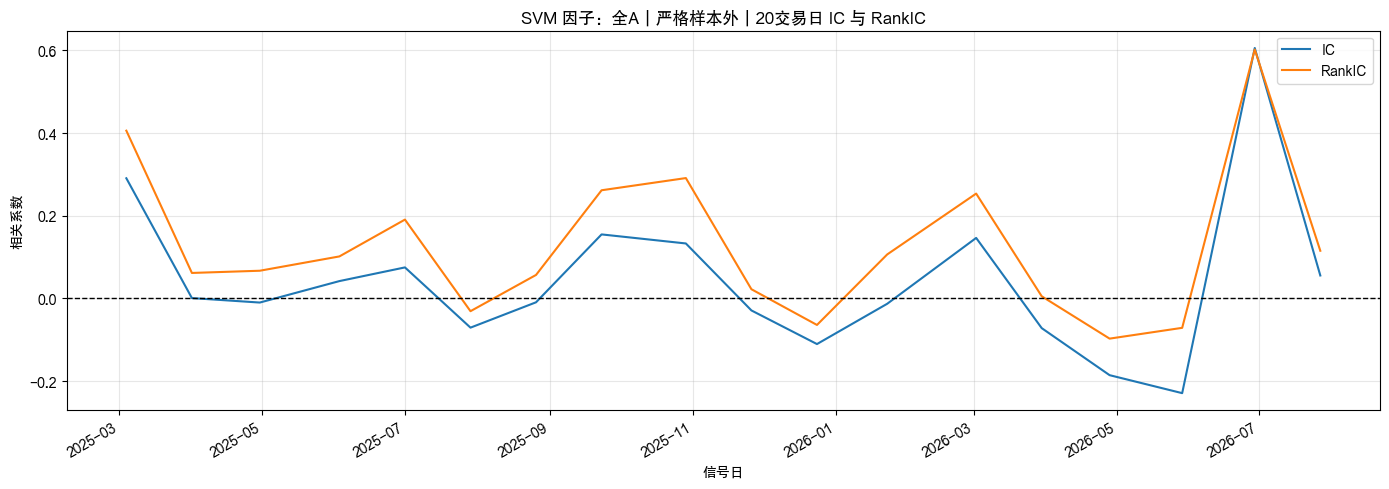

[SVM 基础评价] 计算基础指标与绘制时序图 1/6（16.67%），耗时 1270.6s，预计剩余 6353.1s 市值组1（1=小市值，5=大市值）                                                                                                      

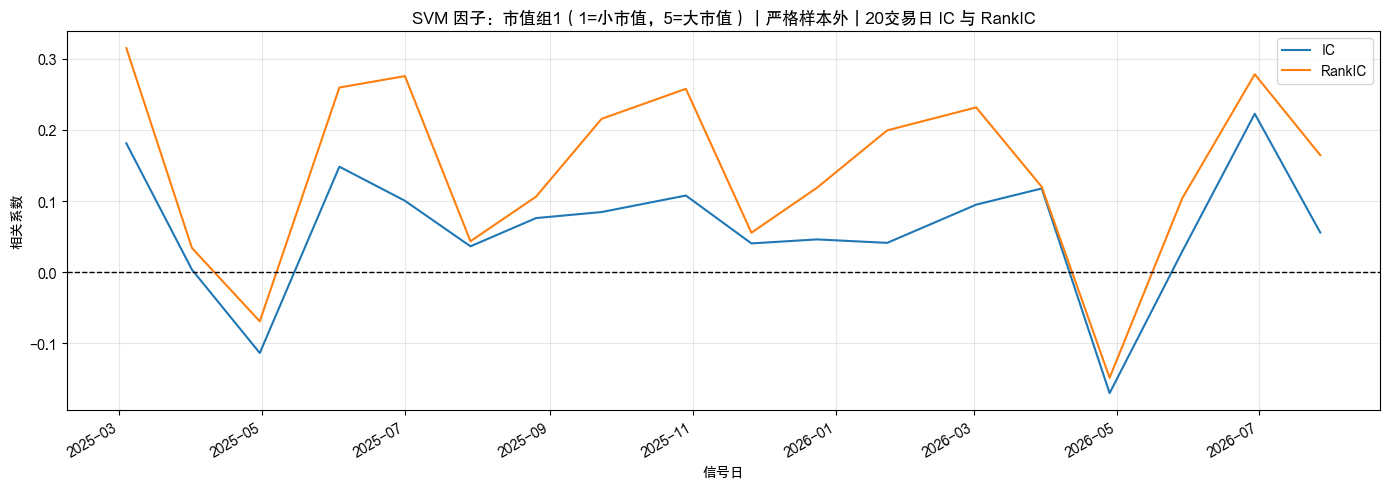

[SVM 基础评价] 计算基础指标与绘制时序图 2/6（33.33%），耗时 1271.0s，预计剩余 2542.1s 市值组2（2=小市值，5=大市值）                                                                                                      

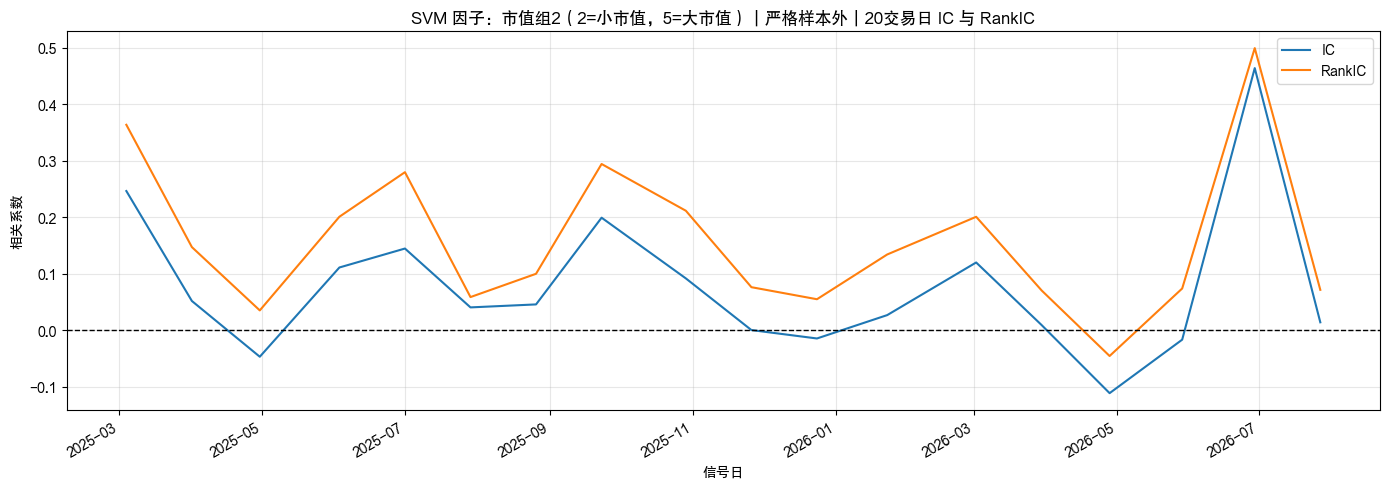

[SVM 基础评价] 计算基础指标与绘制时序图 3/6（50.00%），耗时 1271.5s，预计剩余 1271.5s 市值组3（3=小市值，5=大市值）                                                                                                      

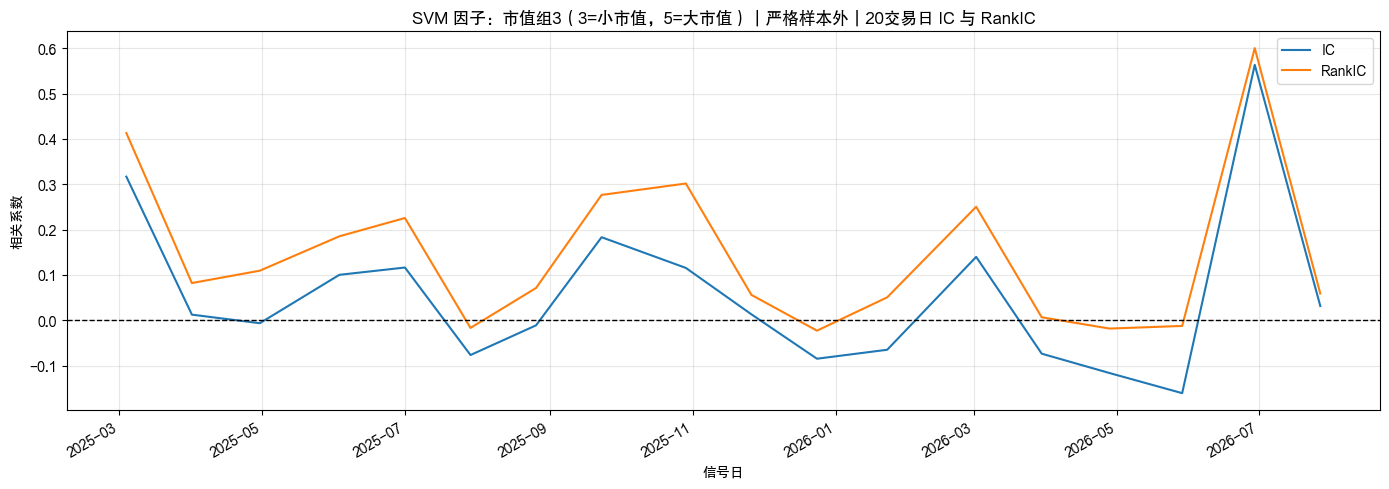

[SVM 基础评价] 计算基础指标与绘制时序图 4/6（66.67%），耗时 1272.0s，预计剩余 636.0s 市值组4（4=小市值，5=大市值）                                                                                                       

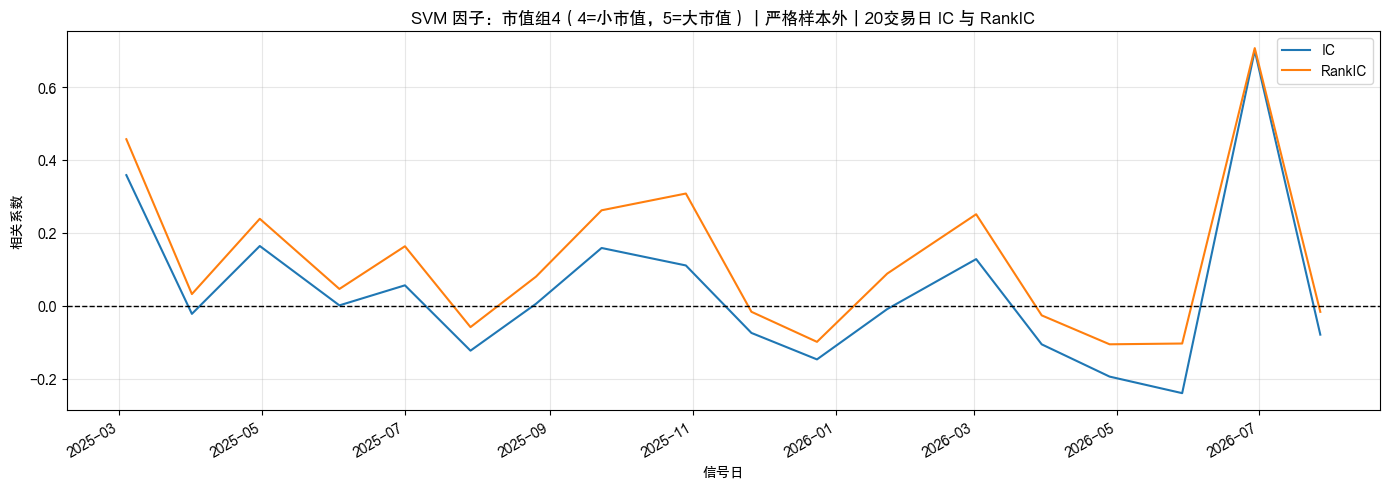

[SVM 基础评价] 计算基础指标与绘制时序图 5/6（83.33%），耗时 1272.4s，预计剩余 254.5s 市值组5（5=小市值，5=大市值）                                                                                                       

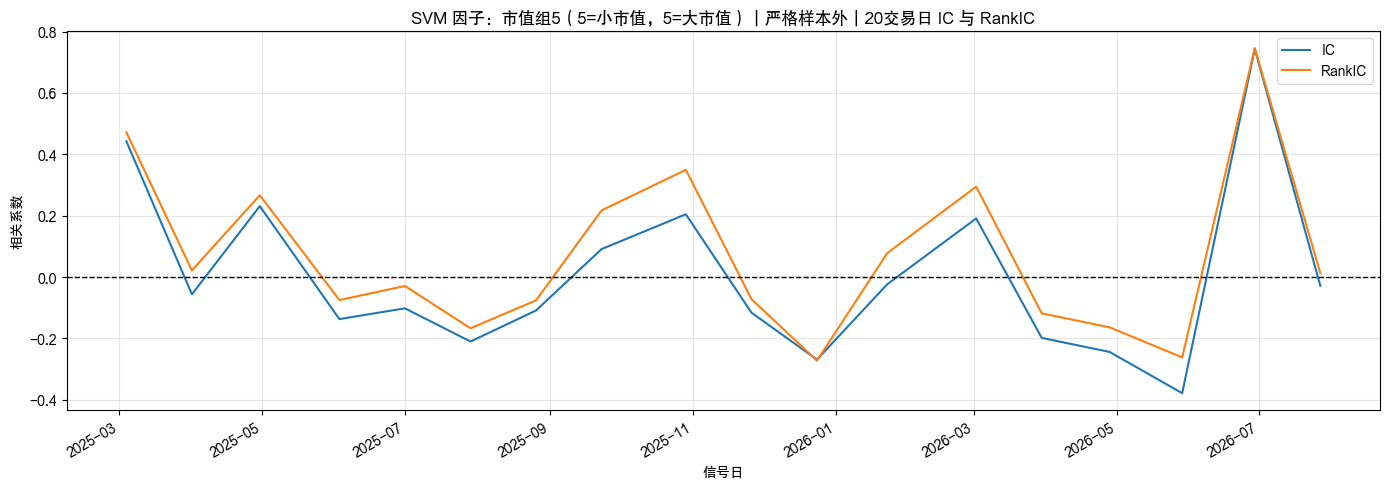

[SVM 基础评价] 计算基础指标与绘制时序图 6/6（100.00%），耗时 1272.9s 市值组5（5=小市值，5=大市值）                                                                                                                  


,evaluation_start_date,information_anchor_date,model_training_anchor_date,signal_interval_trading_days,label_definition,market_cap_group_definition,all_a_signal_date_count
0,2025-02-15,2026-08-28,2025-02-14,20,T+1开盘至T+21开盘，评分股票池等权超额收益,每个信号截面按 total_market_cap 升序等数量分为 5 组,18


,group,factor_column,ic_mean,icir,rank_ic_mean,rank_icir,factor_return_mean,mean_t_value,cross_section_count,valid_ic_count
0,全A,svm_score,0.043023,0.228596,0.126514,0.697401,0.004289,3.842563,18,18
1,市值组1（1=小市值，5=大市值）,svm_score,0.061294,0.659549,0.142330,1.124891,0.007035,2.037283,18,18
2,市值组2（2=小市值，5=大市值）,svm_score,0.076377,0.585047,0.157064,1.164198,0.008922,2.651670,18,18
3,市值组3（3=小市值，5=大市值）,svm_score,0.055366,0.317647,0.145371,0.847322,0.006000,2.076520,18,18
4,市值组4（4=小市值，5=大市值）,svm_score,0.038511,0.174277,0.122859,0.566278,0.003572,1.811886,18,18
5,市值组5（5=小市值，5=大市值）,svm_score,0.001892,0.006828,0.068043,0.250064,-0.003279,0.748939,18,18


,group,signal_date,return_end_date,sample_count,ic,rank_ic,factor_return,factor_t_value
0,全A,2025-03-04,2025-04-02,5371,0.290618,0.405732,0.032124,22.255120
1,全A,2025-04-01,2025-05-06,5368,0.000788,0.061610,0.000086,0.057753
2,全A,2025-04-30,2025-06-04,5372,-0.009999,0.066957,-0.001250,-0.732772
3,全A,2025-06-03,2025-07-02,5376,0.041911,0.101564,0.004590,3.075073
4,全A,2025-07-01,2025-07-30,5394,0.075005,0.190664,0.009401,5.523222
5,全A,2025-07-29,2025-08-27,5404,-0.070707,-0.030897,-0.009412,-5.209860
6,全A,2025-08-26,2025-09-24,5409,-0.009367,0.056792,-0.001265,-0.688792
7,全A,2025-09-23,2025-10-30,5409,0.154827,0.261619,0.018524,11.523724
8,全A,2025-10-29,2025-11-27,5413,0.132930,0.291105,0.016145,9.865790
9,全A,2025-11-26,2025-12-25,5422,-0.029075,0.022199,-0.003784,-2.141457


[SVM 基础评价] 完成：6 个股票池/市值组，总耗时 1272.9s。


In [1]:
# -*- coding: utf-8 -*-
"""用冻结 SVM 模型包计算基础指标：可直接粘贴到 BigQuant Notebook 单元。"""

from __future__ import annotations

import importlib.util
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# ============================== 参数 ==============================
MODEL_ARTIFACT_DIR = Path(
    "/home/aiuser/work/factor_lib/model_artifacts/svm_model_bundles/"
    "svm_all_a_fixed_20260831_223116_5bfc17b8"
)
# 手动指定评价窗口。开始日须晚于模型训练信息截止日；
# 结束日同时是本次评价可使用信息的截止日。
EVALUATION_START_DATE = "2025-02-15"
EVALUATION_END_DATE = "2026-08-28"

MARKET_CAP_GROUP_COUNT = 5
MIN_OBS_PER_CROSS_SECTION = 30
SHOW_CHILD_PROGRESS = True
PROGRESS_EVERY = 5
# 每块只保留两个相邻信号日的十个特征值；原始全 A 面板则逐因子释放。
# 若所用内核内存仍不足，改为 1；数值不会改变，只会增加运行时间。
INFERENCE_BATCH_SIGNAL_DATES = 2


def _timestamp(value, name):
    result = pd.Timestamp(value).normalize()
    if pd.isna(result):
        raise ValueError(f"{name} 不是有效日期：{value!r}")
    return result


def _find_project_root():
    hint = Path(globals().get("PROJECT_ROOT", "/home/aiuser/work")).expanduser()
    candidates = [hint, *hint.parents, Path.cwd(), *Path.cwd().parents]
    root = next(
        (item.resolve() for item in candidates if (item / "factor_lib").is_dir()),
        None,
    )
    if root is None:
        raise FileNotFoundError("未找到项目根目录；BigQuant 中通常为 /home/aiuser/work。")
    return root


def _progress(stage, completed, total, started_at, detail=""):
    ratio = completed / total if total else 1.0
    elapsed = time.perf_counter() - started_at
    eta = ""
    if 0 < completed < total:
        eta = f"，预计剩余 {elapsed / completed * (total - completed):.1f}s"
    print(
        f"\r[SVM 基础评价] {stage} {completed}/{total}（{ratio:.2%}），"
        f"耗时 {elapsed:.1f}s{eta} {detail}".ljust(180),
        end="",
        flush=True,
    )


def _load_svm_module(project_root):
    module_path = (
        project_root / "factor_lib" / "Factor Repository"
        / "machine_learning_factors" / "svm_score.py"
    )
    if not module_path.is_file():
        raise FileNotFoundError(f"找不到 SVM 因子脚本：{module_path}")
    module_spec = importlib.util.spec_from_file_location(
        "svm_score_evaluation",
        module_path,
    )
    if module_spec is None or module_spec.loader is None:
        raise ImportError(f"无法加载 SVM 因子脚本：{module_path}")
    module = importlib.util.module_from_spec(module_spec)
    sys.modules[module_spec.name] = module
    module_spec.loader.exec_module(module)
    return module


def _training_aligned_signal_dates(
    calendar,
    training_start_date,
    effective_start_date,
    information_anchor_date,
    interval,
):
    """从训练首日开始每 interval 个交易日取样，保持训练时的截面相位。"""
    candidates = calendar[
        (calendar >= training_start_date)
        & (calendar <= information_anchor_date)
    ]
    phase_dates = candidates[::int(interval)]
    return phase_dates[phase_dates >= effective_start_date]


def _make_labels(
    score_panel,
    signal_dates,
    calendar,
    information_anchor_date,
    entry_offset,
    exit_offset,
    min_cross_section_size,
    started_at,
):
    """构造训练同口径标签：T+1 开盘至 T+21 开盘、评分股票池等权超额收益。"""
    positions = {date: pos for pos, date in enumerate(calendar)}
    mappings = []
    for signal_date in signal_dates:
        position = positions[signal_date]
        entry_position = position + int(entry_offset)
        exit_position = position + int(exit_offset)
        if exit_position >= len(calendar):
            continue
        exit_date = calendar[exit_position]
        if exit_date <= information_anchor_date:
            mappings.append(
                {
                    "date": signal_date,
                    "entry_date": calendar[entry_position],
                    "return_end_date": exit_date,
                }
            )
    mapping = pd.DataFrame(mappings)
    if mapping.empty:
        raise ValueError("没有完整结束的 20 日标签。")

    _progress("读取评价标签开盘价", 0, 1, started_at, f"{len(mapping)} 个截面")
    price_dates = pd.DatetimeIndex(
        pd.concat([mapping["entry_date"], mapping["return_end_date"]])
    ).unique().sort_values()
    price_panel = load_daily_raw_data(
        standard_fields=["open"],
        dates=price_dates,
        instruments=None,
        show_progress=SHOW_CHILD_PROGRESS,
    )
    _progress("读取评价标签开盘价", 1, 1, started_at, f"{len(price_panel):,} 行")
    print()

    prices = price_panel.loc[:, ["date", "instrument", "open"]].copy()
    prices["date"] = pd.to_datetime(prices["date"], errors="coerce").dt.normalize()
    prices["open"] = pd.to_numeric(prices["open"], errors="coerce")
    prices = prices.loc[
        prices["date"].notna()
        & prices["instrument"].notna()
        & prices["open"].gt(0)
    ].drop_duplicates(["date", "instrument"])

    membership = score_panel.loc[:, ["date", "instrument"]].drop_duplicates()
    labels = membership.merge(mapping, on="date", how="inner", validate="many_to_one")
    labels = labels.merge(
        prices.rename(columns={"date": "entry_date", "open": "entry_open"}),
        on=["entry_date", "instrument"],
        how="left",
        validate="many_to_one",
    ).merge(
        prices.rename(columns={"date": "return_end_date", "open": "exit_open"}),
        on=["return_end_date", "instrument"],
        how="left",
        validate="many_to_one",
    )
    labels["raw_forward_return"] = labels["exit_open"] / labels["entry_open"] - 1.0
    labels = labels.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["raw_forward_return"]
    )

    result_parts = []
    groups = list(labels.groupby("date", sort=True))
    for position, (date, section) in enumerate(groups, start=1):
        if len(section) >= min_cross_section_size:
            section = section.copy()
            # 与训练时一致：每个信号截面相对评分股票池的等权平均收益。
            section["forward_return"] = (
                section["raw_forward_return"] - section["raw_forward_return"].mean()
            )
            result_parts.append(section)
        if (
            position == 1
            or position % PROGRESS_EVERY == 0
            or position == len(groups)
        ):
            _progress(
                "构造训练口径超额收益标签",
                position,
                len(groups),
                started_at,
                f"当前 {date:%Y-%m-%d}",
            )
    print()
    if not result_parts:
        raise ValueError("没有达到最小样本数的评价截面。")
    return pd.concat(result_parts, ignore_index=True).loc[
        :, ["date", "instrument", "forward_return", "return_end_date"]
    ]


def _assign_market_cap_groups(panel, group_count):
    """每个信号截面按 total_market_cap 升序等数量分组；1=小市值，5=大市值。"""
    result_parts = []
    for _, section in panel.groupby("date", sort=True):
        section = section.copy()
        section["market_cap_group"] = pd.NA
        valid = section.loc[
            section["total_market_cap"].notna()
            & section["total_market_cap"].gt(0)
        ].sort_values(["total_market_cap", "instrument"], kind="mergesort")
        if len(valid) >= group_count:
            ranks = pd.Series(np.arange(len(valid)), index=valid.index)
            groups = pd.qcut(
                ranks,
                q=group_count,
                labels=list(range(1, group_count + 1)),
            ).astype("int64")
            section.loc[valid.index, "market_cap_group"] = groups
        result_parts.append(section)
    result = pd.concat(result_parts, ignore_index=True)
    result["market_cap_group"] = result["market_cap_group"].astype("Int64")
    return result


# ============================== 执行 ==============================
started_at = time.perf_counter()
if MARKET_CAP_GROUP_COUNT < 2:
    raise ValueError("MARKET_CAP_GROUP_COUNT 必须至少为 2。")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if not MODEL_ARTIFACT_DIR.is_dir():
    raise FileNotFoundError(f"找不到模型包目录：{MODEL_ARTIFACT_DIR}")

from factor_lib.common.data_adapters.bigquant_adapters.daily import load_daily_raw_data
from factor_lib.common.data_adapters.bigquant_adapters.loader import (
    load_trading_dates,
)
# 复用项目既有的统一横截面指标计算和 IC/RankIC 绘图实现。
from factor_lib.function.bigquant_function.factor_evaluation.calculate_factor_basic_metrics import (
    _calculate_metrics_from_panels,
    _plot_ic_rankic_series,
)

svm_module = _load_svm_module(PROJECT_ROOT)
model_bundle = svm_module.load_svm_model_bundle(MODEL_ARTIFACT_DIR)
training_metadata = model_bundle["training_metadata"]
label_config = model_bundle["label_config"]

training_start_date = _timestamp(
    training_metadata["training_start_date"],
    "training_start_date",
)
training_anchor_date = _timestamp(
    training_metadata["training_anchor_date"],
    "training_anchor_date",
)
evaluation_start_date = _timestamp(EVALUATION_START_DATE, "EVALUATION_START_DATE")
information_anchor_date = _timestamp(EVALUATION_END_DATE, "EVALUATION_END_DATE")
if information_anchor_date <= training_anchor_date:
    raise ValueError(
        "评价信息截止日必须晚于模型 training_anchor_date，才存在严格样本外标签。"
    )
if evaluation_start_date <= training_anchor_date:
    raise ValueError(
        "EVALUATION_START_DATE 必须晚于模型 training_anchor_date，"
        "否则最终重训模型会使用评价期的未来标签。"
    )
if evaluation_start_date > information_anchor_date:
    raise ValueError("EVALUATION_START_DATE 不能晚于 EVALUATION_END_DATE。")

_progress("加载模型包与读取交易日历", 0, 1, started_at)
trading_calendar = pd.DatetimeIndex(
    pd.to_datetime(load_trading_dates(training_start_date, information_anchor_date))
).normalize().unique().sort_values()
_progress("加载模型包与读取交易日历", 1, 1, started_at, f"{len(trading_calendar)} 个交易日")
print()

signal_interval = int(training_metadata["signal_interval_trading_days"])
signal_dates = _training_aligned_signal_dates(
    trading_calendar,
    training_start_date,
    evaluation_start_date,
    information_anchor_date,
    signal_interval,
)
if signal_dates.empty:
    raise ValueError("有效评价区间没有与训练同相位的信号日。")

# 使用 SVM 的流式推理入口：每次只加载一个基础因子的原始数据，完成后立即
# 释放，避免标准 dependencies 路径把十份全 A 原始面板同时留在内存。
_progress("流式读取特征并调用 SVM 推理", 0, 1, started_at, f"{len(signal_dates)} 个信号截面")
svm_score_panel = svm_module.infer_svm_score(
    target_dates=signal_dates,
    as_of_date=information_anchor_date,
    model_artifact_dir=MODEL_ARTIFACT_DIR,
    universe={"type": "all_a"},
    batch_signal_dates=INFERENCE_BATCH_SIGNAL_DATES,
    show_progress=SHOW_CHILD_PROGRESS,
    progress_every=PROGRESS_EVERY,
)
_progress("流式读取特征并调用 SVM 推理", 1, 1, started_at, f"{len(svm_score_panel):,} 行")
print()

required_score_columns = {"date", "instrument", "svm_score"}
missing_score_columns = required_score_columns - set(svm_score_panel.columns)
if missing_score_columns:
    raise ValueError(f"SVM 推理结果缺少字段：{sorted(missing_score_columns)}")
svm_score_panel = svm_score_panel.loc[:, ["date", "instrument", "svm_score"]].copy()
svm_score_panel["date"] = pd.to_datetime(svm_score_panel["date"]).dt.normalize()
svm_score_panel = svm_score_panel.drop_duplicates(["date", "instrument"])

label_panel = _make_labels(
    score_panel=svm_score_panel,
    signal_dates=signal_dates,
    calendar=trading_calendar,
    information_anchor_date=information_anchor_date,
    entry_offset=int(label_config["entry_offset_trading_days"]),
    exit_offset=int(label_config["exit_offset_trading_days"]),
    min_cross_section_size=int(label_config["min_cross_section_size"]),
    started_at=started_at,
)

_progress("读取目标日总市值并划分五组", 0, 1, started_at)
market_cap_panel = load_daily_raw_data(
    standard_fields=["total_market_cap"],
    dates=pd.DatetimeIndex(label_panel["date"].unique()).sort_values(),
    instruments=None,
    show_progress=SHOW_CHILD_PROGRESS,
)
_progress("读取目标日总市值并划分五组", 1, 1, started_at, f"{len(market_cap_panel):,} 行")
print()

market_cap_panel = market_cap_panel.loc[
    :, ["date", "instrument", "total_market_cap"]
].copy()
market_cap_panel["date"] = pd.to_datetime(market_cap_panel["date"]).dt.normalize()
market_cap_panel["total_market_cap"] = pd.to_numeric(
    market_cap_panel["total_market_cap"],
    errors="coerce",
)
market_cap_panel = market_cap_panel.drop_duplicates(["date", "instrument"])

evaluation_panel = (
    svm_score_panel.merge(
        label_panel,
        on=["date", "instrument"],
        how="inner",
        validate="one_to_one",
    ).merge(
        market_cap_panel,
        on=["date", "instrument"],
        how="left",
        validate="one_to_one",
    )
)
evaluation_panel = _assign_market_cap_groups(
    evaluation_panel,
    MARKET_CAP_GROUP_COUNT,
)
if evaluation_panel.empty:
    raise ValueError("SVM 分数、标签和市值数据合并后为空。")

evaluation_results = {}
summary_parts = []
group_definitions = [("全A", None)] + [
    (
        f"市值组{group}（{group}=小市值，{MARKET_CAP_GROUP_COUNT}=大市值）",
        group,
    )
    for group in range(1, MARKET_CAP_GROUP_COUNT + 1)
]
for position, (group_name, group_number) in enumerate(group_definitions, start=1):
    _progress("计算基础指标与绘制时序图", position - 1, len(group_definitions), started_at, group_name)
    group_panel = (
        evaluation_panel
        if group_number is None
        else evaluation_panel.loc[
            evaluation_panel["market_cap_group"] == group_number
        ].copy()
    )
    summary, timeseries = _calculate_metrics_from_panels(
        factor_data=group_panel.loc[:, ["date", "instrument", "svm_score"]],
        label_data=group_panel.loc[
            :, ["date", "instrument", "forward_return", "return_end_date"]
        ],
        factor_column="svm_score",
        min_obs=MIN_OBS_PER_CROSS_SECTION,
        show_progress=False,
        progress_every=PROGRESS_EVERY,
        started_at=started_at,
        stage_number=position,
        stage_total=len(group_definitions),
    )
    summary.insert(0, "group", group_name)
    timeseries.insert(0, "group", group_name)
    figure, axis = _plot_ic_rankic_series(
        metrics_timeseries=timeseries,
        title=(
            f"SVM 因子：{group_name}｜严格样本外｜"
            f"{signal_interval}交易日 IC 与 RankIC"
        ),
        figsize=(14, 5),
        show=True,
    )
    evaluation_results[group_name] = {
        "summary": summary,
        "timeseries": timeseries,
        "figure": figure,
        "axis": axis,
    }
    summary_parts.append(summary)
    _progress("计算基础指标与绘制时序图", position, len(group_definitions), started_at, group_name)
print()

svm_evaluation_summary = pd.concat(summary_parts, ignore_index=True)
svm_evaluation_timeseries = pd.concat(
    [result["timeseries"] for result in evaluation_results.values()],
    ignore_index=True,
)
svm_evaluation_context = pd.DataFrame(
    [{
        "evaluation_start_date": evaluation_start_date.strftime("%Y-%m-%d"),
        "information_anchor_date": information_anchor_date.strftime("%Y-%m-%d"),
        "model_training_anchor_date": training_anchor_date.strftime("%Y-%m-%d"),
        "signal_interval_trading_days": signal_interval,
        "label_definition": "T+1开盘至T+21开盘，评分股票池等权超额收益",
        "market_cap_group_definition": (
            f"每个信号截面按 total_market_cap 升序等数量分为 "
            f"{MARKET_CAP_GROUP_COUNT} 组"
        ),
        "all_a_signal_date_count": int(
            svm_evaluation_timeseries.loc[
                svm_evaluation_timeseries["group"] == "全A",
                "signal_date",
            ].nunique()
        ),
    }]
)

display(svm_evaluation_context)
display(svm_evaluation_summary)
display(svm_evaluation_timeseries.head(12))
print(
    f"[SVM 基础评价] 完成：{len(svm_evaluation_summary)} 个股票池/市值组，"
    f"总耗时 {time.perf_counter() - started_at:.1f}s。",
    flush=True,
)


### 市值分组回测

In [2]:
# -*- coding: utf-8 -*-
"""固定 SVM 因子的市值分组回测：直接粘贴到 BigQuant Notebook 一个单元运行。"""

from __future__ import annotations

import importlib.util
import sys
import time
from pathlib import Path

import pandas as pd
from IPython.display import display


# ============================== 初始参数 ==============================
PROJECT_ROOT = Path(globals().get("PROJECT_ROOT", "/home/aiuser/work"))
MODEL_ARTIFACT_DIR = (
    PROJECT_ROOT
    / "factor_lib"
    / "model_artifacts"
    / "svm_model_bundles"
    / "svm_all_a_fixed_20260831_223116_5bfc17b8"
)

# 模型在 2025-02-14 的信息截止日后才可用于严格样本外回测。
BACKTEST_START_DATE = "2025-02-18"
BACKTEST_END_DATE = "2026-08-28"

# 基础指标显示市值组 1、2 最强；首版先仅在这两组中选股。
MARKET_CAP_GROUP_COUNT = 5
SELECTED_MARKET_CAP_GROUPS = [1]
# svm_score 越高，预测的未来超额收益越高；每组分别选取得分最高 10%。
FACTOR_QUANTILE_RANGE = (0.95, 1.00)
# 与模型训练标签窗口对齐：信号日收盘后形成信号，下一交易日开盘成交并持有约 20 个交易日。
REBALANCE_INTERVAL = 20

INITIAL_CASH = 1_000_000
BENCHMARK = "000300.SH"
TRADING_COSTS = {
    "buy_cost": 0.0003,
    "sell_cost": 0.0003,
    "min_cost": 5.0,
    "tax_ratio": 0.0005,
}
SLIPPAGE_VALUE = 0.001
VOLUME_LIMIT = 0.025
PROGRESS_EVERY = 1


def _find_project_root(root_hint):
    root_hint = Path(root_hint).expanduser()
    candidates = [root_hint, *root_hint.parents, Path.cwd(), *Path.cwd().parents]
    project_root = next(
        (item.resolve() for item in candidates if (item / "factor_lib").is_dir()),
        None,
    )
    if project_root is None:
        raise FileNotFoundError(
            "未找到项目根目录；BigQuant 环境通常应为 /home/aiuser/work。"
        )
    return project_root


def _load_module(module_name, module_path):
    if not module_path.is_file():
        raise FileNotFoundError(f"找不到脚本：{module_path}")
    module_spec = importlib.util.spec_from_file_location(module_name, module_path)
    if module_spec is None or module_spec.loader is None:
        raise ImportError(f"无法加载脚本：{module_path}")
    module = importlib.util.module_from_spec(module_spec)
    sys.modules[module_name] = module
    module_spec.loader.exec_module(module)
    return module


PROJECT_ROOT = _find_project_root(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SVM_MODULE_PATH = (
    PROJECT_ROOT
    / "factor_lib"
    / "Factor Repository"
    / "machine_learning_factors"
    / "svm_score.py"
)
if not MODEL_ARTIFACT_DIR.is_dir():
    raise FileNotFoundError(f"找不到模型包目录：{MODEL_ARTIFACT_DIR}")

svm_module = _load_module("svm_score_market_cap_backtest", SVM_MODULE_PATH)
model_bundle = svm_module.load_svm_model_bundle(MODEL_ARTIFACT_DIR)
training_anchor_date = pd.Timestamp(
    model_bundle["training_metadata"]["training_anchor_date"]
).normalize()
if pd.Timestamp(BACKTEST_START_DATE).normalize() <= training_anchor_date:
    raise ValueError(
        "BACKTEST_START_DATE 必须晚于模型 training_anchor_date "
        f"({training_anchor_date:%Y-%m-%d})。"
    )

from factor_lib.function.bigquant_function.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)


def svm_factor_panel_provider(signal_dates):
    """为公共市值分组回测器按信号日生成内存安全的 SVM 因子面板。"""
    dates = pd.DatetimeIndex(pd.to_datetime(signal_dates)).normalize().unique().sort_values()
    started_at = time.perf_counter()
    score_parts = []
    print(
        f"[SVM 市值分组回测] 开始流式生成 {len(dates)} 个信号日的 svm_score...",
        flush=True,
    )
    for position, signal_date in enumerate(dates, start=1):
        print(
            f"[SVM 市值分组回测] 流式推理 {position}/{len(dates)} "
            f"| 当前 {signal_date:%Y-%m-%d} "
            f"| 已耗时 {time.perf_counter() - started_at:.1f}s",
            flush=True,
        )
        # 每次只允许使用该信号日及此前信息，避免批量推理时把后续日期
        # 误作为早期信号的 as_of_date，同时控制单次特征原始数据的内存峰值。
        score_parts.append(
            svm_module.infer_svm_score(
                target_dates=[signal_date],
                model_bundle=model_bundle,
                universe={"type": "all_a"},
                as_of_date=signal_date,
                batch_signal_dates=1,
                show_progress=True,
                progress_every=1,
            )
        )
    score_panel = pd.concat(score_parts, axis=0, ignore_index=True)
    required = {"date", "instrument", "svm_score"}
    missing = required - set(score_panel.columns)
    if missing:
        raise ValueError(f"SVM 推理结果缺少字段：{sorted(missing)}")
    score_panel = score_panel.loc[:, ["date", "instrument", "svm_score"]].copy()
    score_panel["date"] = pd.to_datetime(score_panel["date"]).dt.normalize()
    score_panel = score_panel.drop_duplicates(["date", "instrument"])
    print(
        f"[SVM 市值分组回测] 因子面板完成：{len(score_panel):,} 行。",
        flush=True,
    )
    return score_panel


svm_market_cap_backtest_result = run_market_cap_group_backtest(
    start_date=BACKTEST_START_DATE,
    end_date=BACKTEST_END_DATE,
    rebalance_interval=REBALANCE_INTERVAL,
    universe={"type": "all_a"},
    factor_name="svm_score",
    market_cap_group_count=MARKET_CAP_GROUP_COUNT,
    selected_market_cap_groups=SELECTED_MARKET_CAP_GROUPS,
    factor_quantile_range=FACTOR_QUANTILE_RANGE,
    factor_params=None,
    factor_panel_provider=svm_factor_panel_provider,
    order_price_field_buy="open",
    order_price_field_sell="open",
    initial_cash=INITIAL_CASH,
    benchmark=BENCHMARK,
    trading_costs=TRADING_COSTS,
    slippage_value=SLIPPAGE_VALUE,
    volume_limit=VOLUME_LIMIT,
    show_progress=True,
    progress_every=PROGRESS_EVERY,
)

# 仅展示核心审计摘要；完整信号、订单和成交记录保留在返回对象中。
display(pd.DataFrame([svm_market_cap_backtest_result["data_diagnostics"]]))
display(svm_market_cap_backtest_result["rebalance_audit"].tail(10))
svm_market_cap_backtest_result["performance"]


[市值分组回测] [2/8] 调用流式因子面板提供器 | 0/1 (0.0%) | 当前 svm_score | 19个信号日 | 已耗时 0.6s                                                                                                                                                  [SVM 市值分组回测] 开始流式生成 19 个信号日的 svm_score...
[SVM 市值分组回测] 流式推理 1/19 | 当前 2025-02-17 | 已耗时 0.0s
[BigQuant 日频适配器] [3/3] 查询结果校验完成 | 1/1 (100.0%) | 344,386 行 | 已耗时 7.2s                                                                                                                                                       
[BigQuant 市场日频适配器] [3/3] 市场日频数据准备完成 | 64 行 | 已耗时 0.4s                                                                                                                              
[BigQuant loader] 2/2（100.00%），数据域合并完成，当前 market_daily，64 行，耗时 7.8s                                                                                                                
[id2_std_nm] [2/2] 回归和中性化 1/1 | 100.0% | 当前：2025-02-17 | 已耗时：2.5s | 预计剩余：0.0s0.0s                          

[2026-09-01 21:29:50] [info     ] bigtrader.v35 运行完成 [12.185s].
[市值分组回测] [8/8] 回测与审计结果整理完成 | 1/1 (100.0%) | 信号1,010条，订单3,106条，成交1,553条 | 已耗时 1963.6s                                                                                                                                        


,requested_start_date,actual_first_execution_date,engine_start_date,end_date,factor_history_days,factor_loading_mode,resolved_factor_params,factor_raw_rows,factor_domain_rows,provided_factor_rows,signal_state_rows,execution_state_rows,engine_instrument_count,scheduled_rebalance_count,processed_signal_count,successful_signal_count,total_runtime_seconds
0,2025-02-18,2025-02-18,2025-02-17,2026-08-28,None,factor_panel_provider,{},0,{},103693,103693,103701,5588,19,19,19,1963.627676


,rebalance_number,signal_date,execution_date,status,error_message,candidate_count,eligible_count,actual_group_count,group_populations,selected_counts,target_count
9,10,2025-11-11,2025-11-12,ok,,5448,5265,5,"{1: 1053, 2: 1053, 3: 1053, 4: 1053, 5: 1053}","{1: 53, 2: 0, 3: 0, 4: 0, 5: 0}",53
10,11,2025-12-09,2025-12-10,ok,,5456,5268,5,"{1: 1054, 2: 1053, 3: 1054, 4: 1053, 5: 1054}","{1: 53, 2: 0, 3: 0, 4: 0, 5: 0}",53
11,12,2026-01-08,2026-01-09,ok,,5470,5282,5,"{1: 1057, 2: 1056, 3: 1056, 4: 1056, 5: 1057}","{1: 53, 2: 0, 3: 0, 4: 0, 5: 0}",53
12,13,2026-02-05,2026-02-06,ok,,5479,5293,5,"{1: 1059, 2: 1058, 3: 1059, 4: 1058, 5: 1059}","{1: 53, 2: 0, 3: 0, 4: 0, 5: 0}",53
13,14,2026-03-13,2026-03-16,ok,,5489,5307,5,"{1: 1062, 2: 1061, 3: 1061, 4: 1061, 5: 1062}","{1: 54, 2: 0, 3: 0, 4: 0, 5: 0}",54
14,15,2026-04-13,2026-04-14,ok,,5502,5317,5,"{1: 1064, 2: 1063, 3: 1063, 4: 1063, 5: 1064}","{1: 54, 2: 0, 3: 0, 4: 0, 5: 0}",54
15,16,2026-05-14,2026-05-15,ok,,5515,5245,5,"{1: 1049, 2: 1049, 3: 1049, 4: 1049, 5: 1049}","{1: 53, 2: 0, 3: 0, 4: 0, 5: 0}",53
16,17,2026-06-11,2026-06-12,ok,,5527,5277,5,"{1: 1056, 2: 1055, 3: 1055, 4: 1055, 5: 1056}","{1: 53, 2: 0, 3: 0, 4: 0, 5: 0}",53
17,18,2026-07-10,2026-07-13,ok,,5530,5306,5,"{1: 1062, 2: 1061, 3: 1061, 4: 1061, 5: 1061}","{1: 54, 2: 0, 3: 0, 4: 0, 5: 0}",54
18,19,2026-08-07,2026-08-10,ok,,5539,5329,5,"{1: 1066, 2: 1066, 3: 1065, 4: 1066, 5: 1066}","{1: 54, 2: 0, 3: 0, 4: 0, 5: 0}",54


{'raw_perf': dai.DataSource("_e23b1db6ba51480781e456d289b8d150"), 'order_price_field_buy': 'open', 'order_price_field_sell': 'open', 'plot_charts': True, 'start_date': '2025-02-17', 'end_date': '2026-08-28', 'capital_base': 1000000.0, 'instruments': None, 'frequency': '1d', 'benchmark': '000300.SH', 'product_type': 'equity', 'before_start_days': 0, 'volume_limit': 0.025, 'benchmark_data': None, 'basic_data': None, 'dominant_data': None, 'options_data': None, 'debug': False, 'perf_round_num': 4, 'strategy_name': None, 'run_begin_time': '2026-09-01 21:29:37', 'run_mode': 'backtest', 'run_engine': 'py', 'render': <bound method render of {...}>, 'display': <bound method render of {...}>, 'read_raw_perf': <bound method read_raw_perf of {...}>, 'analyze_pnl_per_trade': <bound method analyze_pnl_per_trade of {...}>, 'analyze_pnl_per_day': <bound method analyze_pnl_per_day of {...}>, 'plot_return_curve_per_stock': <bound method plot_return_curve_per_stock of {...}>, 'plot_curve_return': <bound